In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import load_npz, csr_matrix

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
# load the cleaned music information, user and track IDs,
# and the user-song interaction matrix

interaction_matrix = load_npz("data/interaction_matrix.npz")

user_ids = np.load("user_ids.npy", allow_pickle=True)

track_ids = np.load("track_ids.npy", allow_pickle=True)

music_df = pd.read_csv("data/music_info_clean.csv")

print("Data loaded successfully.")

Data loaded successfully.


In [ ]:
# check that the dimensions of the interaction matrix match
# the number of user IDs and track IDs

print("Interaction matrix shape:")
print(interaction_matrix.shape)

print("\nNumber of users:")
print(len(user_ids))

print("\nNumber of tracks in interaction matrix:")
print(len(track_ids))

print("\nMusic metadata shape:")
print(music_df.shape)

print("\nNumber of tracks in metadata:")
print(music_df["track_id"].nunique())

Interaction matrix shape:
(290898, 29922)

Number of users:
290898

Number of tracks in interaction matrix:
29922

Music metadata shape:
(50673, 21)

Number of tracks in metadata:
50673


In [ ]:
# create mappings between user/track IDs and their corresponding
# row or column indices in the interaction matrix

assert interaction_matrix.shape[0] == len(user_ids)
assert interaction_matrix.shape[1] == len(track_ids)

print("User mapping verified.")
print("Track mapping verified.")

User mapping verified.
Track mapping verified.


In [ ]:
# create a lookup structure for converting track indices from the
# interaction matrix back into track IDs and readable song information

music_track_ids = set(music_df["track_id"])

matched_tracks = sum(track_id in music_track_ids for track_id in track_ids)

print(
    f"{matched_tracks:,} / {len(track_ids):,} interaction tracks found in music dataset"
)

29,915 / 29,922 interaction tracks found in music dataset


In [ ]:
# examine the stored interactions in the matrix to understand
# how listening activity is represented

track_lookup = music_df[["track_id", "name", "artist", "genre"]].copy()

track_lookup.head()

track_lookup = track_lookup.set_index("track_id")

track_lookup.head()

,name,artist,genre
track_id,,,
TRIOREW128F424EAF0,Mr. Brightside,The Killers,Unkown
TRRIVDJ128F429B0E8,Wonderwall,Oasis,Unkown
TROUVHL128F426C441,Come as You Are,Nirvana,RnB
TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,Unkown
TRLNZBD128F935E4D8,Creep,Radiohead,RnB


In [ ]:
# calculate the sparsity of the user-song interaction matrix
# helps demonstrate the difference between the music catalogue and
# the number of songs each user has interacted with

print("Number of stored interactions:")
print(interaction_matrix.nnz)

print("\nMinimum playcount:")
print(interaction_matrix.data.min())

print("\nMaximum playcount:")
print(interaction_matrix.data.max())

print("\nAverage playcount among stored interactions:")
print(interaction_matrix.data.mean())

Number of stored interactions:
7070360

Minimum playcount:
1

Maximum playcount:
1862

Average playcount among stored interactions:
2.4611924993918275


In [ ]:
# calculate how many unique songs users have interacted with
# to understand the distribution of listening activity across users

total_possible_interactions = interaction_matrix.shape[0] * interaction_matrix.shape[1]

actual_interactions = interaction_matrix.nnz

sparsity = 1 - actual_interactions / total_possible_interactions

print(f"Total possible user-song pairs: {total_possible_interactions:,}")

print(f"Observed interactions: {actual_interactions:,}")

print(f"Sparsity: {sparsity:.4%}")

Total possible user-song pairs: 8,704,249,956
Observed interactions: 7,070,360
Sparsity: 99.9188%


In [43]:
# Number of songs each user has interacted with
user_interaction_counts = np.diff(interaction_matrix.indptr)

print("Average songs per user:", user_interaction_counts.mean())

print("Median songs per user:", np.median(user_interaction_counts))

print("Minimum songs per user:", user_interaction_counts.min())

print("Maximum songs per user:", user_interaction_counts.max())

Average songs per user: 24.30528913914843
Median songs per user: 18.0
Minimum songs per user: 10
Maximum songs per user: 784


In [44]:
# Percentage of the available catalogue each user has interacted with
catalogue_size = interaction_matrix.shape[1]

user_catalogue_percentage = (user_interaction_counts / catalogue_size) * 100

print(
    "Average percentage of catalogue interacted with:", user_catalogue_percentage.mean()
)

print(
    "Median percentage of catalogue interacted with:",
    np.median(user_catalogue_percentage),
)

Average percentage of catalogue interacted with: 0.08122882540989385
Median percentage of catalogue interacted with: 0.060156406657309


In [ ]:
# split each user's interactions into training and testing sets
# the training interactions are used to generate recommendations
# the testing interactions are used during evaluation
def train_test_split_sparse(interaction_matrix, test_ratio=0.2, random_state=42):

    rng = np.random.default_rng(random_state)

    train_rows = []
    train_cols = []
    train_values = []

    test_rows = []
    test_cols = []
    test_values = []

    for user_idx in range(interaction_matrix.shape[0]):
        start = interaction_matrix.indptr[user_idx]
        end = interaction_matrix.indptr[user_idx + 1]

        user_items = interaction_matrix.indices[start:end]

        user_values = interaction_matrix.data[start:end]

        if len(user_items) < 2:
            train_rows.extend([user_idx] * len(user_items))

            train_cols.extend(user_items)

            train_values.extend(user_values)

            continue

        shuffled = rng.permutation(len(user_items))

        test_size = max(1, int(len(user_items) * test_ratio))

        test_size = min(test_size, len(user_items) - 1)

        test_positions = shuffled[:test_size]

        train_positions = shuffled[test_size:]

        train_rows.extend([user_idx] * len(train_positions))

        train_cols.extend(user_items[train_positions])

        train_values.extend(user_values[train_positions])

        test_rows.extend([user_idx] * len(test_positions))

        test_cols.extend(user_items[test_positions])

        test_values.extend(user_values[test_positions])

    train_matrix = csr_matrix(
        (train_values, (train_rows, train_cols)), shape=interaction_matrix.shape
    )

    test_matrix = csr_matrix(
        (test_values, (test_rows, test_cols)), shape=interaction_matrix.shape
    )

    return train_matrix, test_matrix

In [ ]:
# create separate sparse matrices containing the training and testing interactions
#  while preserving the original user and track indexing

train_matrix, test_matrix = train_test_split_sparse(
    interaction_matrix, test_ratio=0.2, random_state=42
)

print("Original interactions:", interaction_matrix.nnz)
print("Training interactions:", train_matrix.nnz)
print("Testing interactions:", test_matrix.nnz)

Original interactions: 7070360
Training interactions: 5760956
Testing interactions: 1309404


In [ ]:
# check that interactions assigned to the test set are not also present in the
# training set

overlap = train_matrix.multiply(test_matrix)

print("Overlapping train/test interactions:", overlap.nnz)

Overlapping train/test interactions: 0


In [ ]:
# identify users who have at least one held-out interaction
# in the test set so that they can be evaluated

train_user_counts = np.diff(train_matrix.indptr)

test_user_counts = np.diff(test_matrix.indptr)

evaluatable_users = np.where(test_user_counts > 0)[0]

print("Total users:", interaction_matrix.shape[0])

print("Users with test interactions:", len(evaluatable_users))

print(
    "Percentage of users evaluated:",
    len(evaluatable_users) / interaction_matrix.shape[0] * 100,
)

Total users: 290898
Users with test interactions: 290898
Percentage of users evaluated: 100.0


In [ ]:
# create dictionaries that allow user and track IDs to be converted to the row
# and column indices required by the interaction matrices

# Map actual user IDs to matrix indices
user_to_idx = {user_id: idx for idx, user_id in enumerate(user_ids)}

# Map matrix indices back to actual user IDs
idx_to_user = {idx: user_id for idx, user_id in enumerate(user_ids)}

# Map actual track IDs to matrix indices
track_to_idx = {track_id: idx for idx, track_id in enumerate(track_ids)}

# Map matrix indices back to actual track IDs
idx_to_track = {idx: track_id for idx, track_id in enumerate(track_ids)}

print("User mappings:", len(user_to_idx))
print("Track mappings:", len(track_to_idx))

User mappings: 290898
Track mappings: 29922


In [ ]:
# adapt the recommendation system to use the training interaction matrix
# and calculate cosine similarity between users based on their listening patterns


def find_similar_users_eval(user_id, matrix, top_n=5):
    if user_id not in user_to_idx:
        return []

    user_index = user_to_idx[user_id]

    target_user = matrix[user_index]

    similarities = cosine_similarity(target_user, matrix).flatten()

    # exclude the target user
    similarities[user_index] = -1

    similar_indices = similarities.argsort()[::-1][:top_n]

    similar_users = []

    for index in similar_indices:
        similar_users.append((idx_to_user[index], similarities[index]))

    return similar_users

In [ ]:
def recommend_songs_eval(user_id, matrix, top_users=5, top_songs=5):
    if user_id not in user_to_idx:
        return []

    # Find similar users
    similar_users = find_similar_users_eval(user_id, matrix, top_n=top_users)

    user_index = user_to_idx[user_id]

    # Target user's training history
    target_vector = matrix[user_index]

    # Songs already seen during training
    listened_tracks = set(target_vector.indices)

    recommendation_scores = {}

    # Look at songs listened to by similar users
    for similar_user_id, similarity_score in similar_users:
        similar_user_index = user_to_idx[similar_user_id]

        similar_user_vector = matrix[similar_user_index]

        for track_index, playcount in zip(
            similar_user_vector.indices, similar_user_vector.data
        ):
            # Don't recommend songs already
            # present in the training history
            if track_index in listened_tracks:
                continue

            # Same scoring method as Member 2
            score = similarity_score * playcount

            if track_index in recommendation_scores:
                recommendation_scores[track_index] += score

            else:
                recommendation_scores[track_index] = score

    # Rank songs by recommendation score
    sorted_tracks = sorted(
        recommendation_scores.items(), key=lambda x: x[1], reverse=True
    )

    return sorted_tracks[:top_songs]

In [ ]:
def precision_at_k(recommended_items, relevant_items, k):
    recommended_items = recommended_items[:k]

    if len(recommended_items) == 0:
        return 0.0

    recommended_set = set(recommended_items)

    relevant_set = set(relevant_items)

    hits = len(recommended_set & relevant_set)

    return hits / len(recommended_items)

In [ ]:
def recall_at_k(recommended_items, relevant_items, k):
    if len(relevant_items) == 0:
        return 0.0

    recommended_items = recommended_items[:k]

    recommended_set = set(recommended_items)

    relevant_set = set(relevant_items)

    hits = len(recommended_set & relevant_set)

    return hits / len(relevant_set)

In [25]:
def f1_at_k(recommended_items, relevant_items, k):
    """
    Calculate the harmonic mean of Precision@K
    and Recall@K.
    """

    precision = precision_at_k(recommended_items, relevant_items, k)

    recall = recall_at_k(recommended_items, relevant_items, k)

    if precision + recall == 0:
        return 0.0

    return 2 * precision * recall / (precision + recall)

In [ ]:
N_EVAL_USERS = 100

rng = np.random.default_rng(42)

eval_user_indices = rng.choice(
    evaluatable_users, size=min(N_EVAL_USERS, len(evaluatable_users)), replace=False
)

eval_user_ids = [idx_to_user[idx] for idx in eval_user_indices]

print("Users selected for evaluation:", len(eval_user_ids))

Users selected for evaluation: 100


In [ ]:
# run the recommender for 100 users
# calculate Precision@5, Recall@5, and F1@5 for each user

results = []

for i, user_id in enumerate(eval_user_ids):
    user_index = user_to_idx[user_id]

    # Get the user's held-out test interactions
    test_items = list(test_matrix[user_index].indices)

    # Generate recommendations using ONLY training data
    recommendations = recommend_songs_eval(
        user_id, train_matrix, top_users=5, top_songs=5
    )

    # Extract recommended track indices
    recommended_items = [track_index for track_index, score in recommendations]

    # Calculate metrics
    precision = precision_at_k(recommended_items, test_items, 5)

    recall = recall_at_k(recommended_items, test_items, 5)

    f1 = f1_at_k(recommended_items, test_items, 5)

    results.append(
        {"user_id": user_id, "precision@5": precision, "recall@5": recall, "f1@5": f1}
    )

    # Progress indicator
    if (i + 1) % 10 == 0:
        print(f"Evaluated {i + 1}/{len(eval_user_ids)} users")

Evaluated 10/100 users
Evaluated 20/100 users
Evaluated 30/100 users
Evaluated 40/100 users
Evaluated 50/100 users
Evaluated 60/100 users
Evaluated 70/100 users
Evaluated 80/100 users
Evaluated 90/100 users
Evaluated 100/100 users


In [ ]:
# store the individual users' evaluation scores in a dataframe
# to be used for further analysis

evaluation_results = pd.DataFrame(results)

evaluation_results.head()

,user_id,precision@5,recall@5,f1@5
0,5bc9d1465f27102aa4c03c4bd36c24d5064db0b5,0.0,0.000000,0.000000
1,77ab0bd73f86208bd01288756ef2ace27c89a544,0.0,0.000000,0.000000
2,365aed1f521963b2eba65125c13c8c09e474c708,0.0,0.000000,0.000000
3,522e888e08be8952587d8dc91f09745b98951d96,0.4,0.500000,0.444444
4,719999f23d646039139952daff6a16398b87ab57,0.2,0.090909,0.125000


In [ ]:
# calculate the mean Precision@5, Recall@5, and F1@5 across the evaluated users

average_precision = evaluation_results["precision@5"].mean()

average_recall = evaluation_results["recall@5"].mean()

average_f1 = evaluation_results["f1@5"].mean()

print(f"Average Precision@5: {average_precision:.4f}")

print(f"Average Recall@5: {average_recall:.4f}")

print(f"Average F1@5: {average_f1:.4f}")

Average Precision@5: 0.0660
Average Recall@5: 0.0758
Average F1@5: 0.0645


In [ ]:
# evaluate the recommendation system using K = 5, 10, and 20 to investigate how the
# number of recommended songs affects precision, recall, and F1

K_VALUES = [5, 10, 20]

results_by_k = {k: [] for k in K_VALUES}

for i, user_id in enumerate(eval_user_ids):
    user_index = user_to_idx[user_id]

    # Ground-truth songs from the test set
    test_items = list(test_matrix[user_index].indices)

    # Generate up to 20 recommendations
    recommendations = recommend_songs_eval(
        user_id, train_matrix, top_users=5, top_songs=20
    )

    recommended_items = [track_index for track_index, score in recommendations]

    # Calculate metrics for each K
    for k in K_VALUES:
        precision = precision_at_k(recommended_items, test_items, k)

        recall = recall_at_k(recommended_items, test_items, k)

        f1 = f1_at_k(recommended_items, test_items, k)

        results_by_k[k].append(
            {"user_id": user_id, "precision": precision, "recall": recall, "f1": f1}
        )

    if (i + 1) % 10 == 0:
        print(f"Evaluated {i + 1}/{len(eval_user_ids)} users")

Evaluated 10/100 users
Evaluated 20/100 users
Evaluated 30/100 users
Evaluated 40/100 users
Evaluated 50/100 users
Evaluated 60/100 users
Evaluated 70/100 users
Evaluated 80/100 users
Evaluated 90/100 users
Evaluated 100/100 users


In [ ]:
# create a summary table showing the average
# precision, recall, and f1 scores for each recommendation size

k_summary = []

for k in K_VALUES:
    k_results = pd.DataFrame(results_by_k[k])

    k_summary.append(
        {
            "K": k,
            "Precision": k_results["precision"].mean(),
            "Recall": k_results["recall"].mean(),
            "F1": k_results["f1"].mean(),
        }
    )

k_summary = pd.DataFrame(k_summary)

k_summary

,K,Precision,Recall,F1
0,5,0.0660,0.075827,0.064541
1,10,0.0400,0.087271,0.050818
2,20,0.0265,0.112165,0.040355


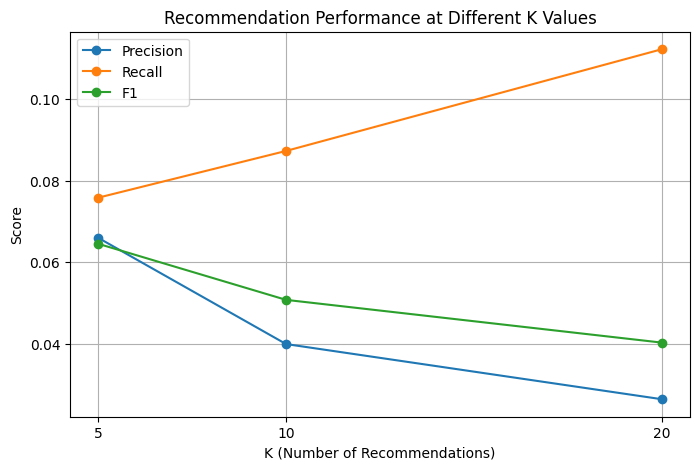

In [ ]:
# plot precision, recall, and f1 scores for K = 5, 10, and 20

plt.figure(figsize=(8, 5))

plt.plot(k_summary["K"], k_summary["Precision"], marker="o", label="Precision")

plt.plot(k_summary["K"], k_summary["Recall"], marker="o", label="Recall")

plt.plot(k_summary["K"], k_summary["F1"], marker="o", label="F1")

plt.xlabel("K (Number of Recommendations)")
plt.ylabel("Score")
plt.title("Recommendation Performance at Different K Values")
plt.xticks(K_VALUES)
plt.legend()
plt.grid(True)

plt.show()

The recommendation system was evaluated using a train/test split of the user-song interaction data. The recommender was evaluated on 100 users using Precision@K, Recall@K, and F1@K, with K values of 5, 10, and 20.

The results showed a trade-off between precision and recall. At K=5, the system achieved a Precision of 0.0660, Recall of 0.0758, and F1 score of 0.0645. When the number of recommendations increased to K=10, precision decreased to 0.0400, while recall increased to 0.0873. At K=20, precision decreased further to 0.0265, but recall increased to 0.1122. This indicates that providing more recommendations allows the system to retrieve more of the songs that users interacted with, but also introduces more irrelevant recommendations.

Among the tested values, K=5 produced the highest F1 score (0.0645), making it the best-performing recommendation size based on the balance between precision and recall. Overall, the results suggest that recommending a smaller number of songs provides more relevant recommendations, while larger recommendation lists provide greater coverage at the cost of relevance.

The relatively low scores can partly be understood in the context of the dataset. There is a large difference between the total number of available songs and the number of songs individual users have interacted with, resulting in a sparse user-song interaction matrix. The system also relies on the listening patterns of only the most similar users, which can limit the number of relevant songs available for recommendation. Additionally, the evaluation was performed on a sample of 100 users rather than the entire dataset, so the results may not represent every user. Finally, listening history does not necessarily represent explicit user preferences, meaning that a held-out interaction may not always indicate that a user would consider a recommendation desirable.

Overall, the evaluation demonstrates that the recommender is capable of identifying some relevant songs, but its performance is limited by the sparsity of the interaction data and the user-based similarity approach. K=5 provides the best balance between recommendation relevance and coverage among the tested values.